In [1]:
import torch
import torch.nn.functional as F
import contextlib
import torch
import numpy as np
from diffusers import StableDiffusionInpaintPipeline, AutoencoderKL
from PIL import Image, ImageFilter, ImageDraw
from torch.utils.tensorboard import SummaryWriter
import datetime

import contextlib
import torch.nn.functional as F


# Funzioni di utilità per lo spostamento (basate su pipeline.py di Vecchio)
def roll(x):
    # Calcola uno shift casuale per forzare la continuità dei bordi
    roll_h = torch.randint(0, x.shape[-2], (1,)).item() // 2 * 2
    roll_w = torch.randint(0, x.shape[-1], (1,)).item() // 2 * 2
    x = torch.roll(x, shifts=(roll_h, roll_w), dims=(-2, -1))
    return x, (roll_h, roll_w)

def unroll(x, roll_h, roll_w, factor=1.0):
    # Riporta i dati nella posizione originale in base alla scala del layer
    roll_h = int(roll_h * factor)
    roll_w = int(roll_w * factor)
    x = torch.roll(x, shifts=(-roll_h, -roll_w), dims=(-2, -1))
    return x

@contextlib.contextmanager
def feature_rolling_mode(enabled=True):
    """
    Context manager che modifica temporaneamente tutte le convoluzioni 2D 
    per supportare il rolling e il padding circolare.
    """
    if not enabled:
        yield
        return

    # Salviamo il forward originale
    orig_forward = torch.nn.Conv2d.forward

    def new_forward(self, x, *args, **kwargs):
        # 1. Applichiamo il rolling all'input del layer
        x, (rh, rw) = roll(x)
        
        # 2. Applichiamo il Padding Circolare (fondamentale per la precisione)
        # Sostituiamo il padding standard con quello 'tiled'
        orig_padding = self.padding
        pad = orig_padding[0]
        if pad > 0:
            x = F.pad(x, (pad, pad, pad, pad), mode="circular")
            self.padding = (0, 0) # Azzeriamo per non rifarlo internamente
        
        # 3. Convoluzione originale
        h_in = x.shape[-2]
        result = orig_forward(self, x, *args, **kwargs)
        
        # 4. Unrolling del risultato
        # Il fattore serve perché la risoluzione cambia nei vari blocchi della UNet
        factor = result.shape[-2] / h_in
        result = unroll(result, rh, rw, factor)
        
        # Ripristiniamo il padding originale per il prossimo utilizzo del layer
        self.padding = orig_padding
        return result

    # Patching dinamico
    torch.nn.Conv2d.forward = new_forward
    try:
        yield
    finally:
        # Ripristino obbligatorio per non rompere il modello dopo l'uso
        torch.nn.Conv2d.forward = orig_forward

/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
log_dir = "runs/esperimento_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir)

device = "cuda"
model_id = "sd-legacy/stable-diffusion-inpainting"
adapter_id = "h94/IP-Adapter"

In [3]:
vae = AutoencoderKL.from_pretrained(
    "stabilityai/sd-vae-ft-mse",
    torch_dtype=torch.float16
).to(device)

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id, 
    use_safetensors=False,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
    vae = vae
).to(device)

/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]/export/home/federica.digiaimo2/miniconda3/envs/rectification/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  3.87it/s]


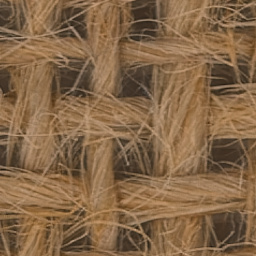

In [4]:
BASE_SIZE = 512
INNER_SIZE = 256
OFFSET = (BASE_SIZE - INNER_SIZE) // 2 

try:
    input_image = Image.open("juta2.jpg").convert("RGB")
    width, height = input_image.size

    left = (width - INNER_SIZE) / 2
    top = (height - INNER_SIZE) / 2
    right = (width + INNER_SIZE) / 2
    bottom = (height + INNER_SIZE) / 2
    input_image = input_image.crop((left, top, right, bottom))

except:
    print("Immagine non trovata.")
    input_image = Image.new("RGB", (INNER_SIZE, INNER_SIZE), "red")

input_image.save("prova_1cropped_2.png")
display(input_image)

In [5]:
width, height = input_image.size

left = (width - INNER_SIZE) / 2
top = (height - INNER_SIZE) / 2
right = (width + INNER_SIZE) / 2
bottom = (height + INNER_SIZE) / 2
small_texture = input_image.crop((left, top, right, bottom))

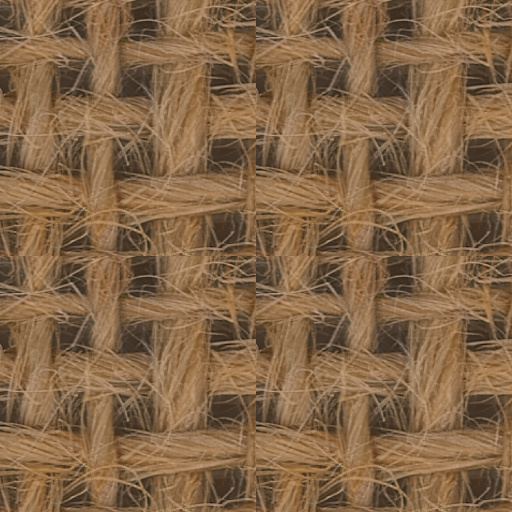

In [6]:
bg_hint = Image.new("RGB", (BASE_SIZE, BASE_SIZE), "white") 
canvas = bg_hint.copy()
canvas.paste(small_texture, (OFFSET, OFFSET))

mask = Image.new("L", (BASE_SIZE, BASE_SIZE), 255)
mask_center = Image.new("L", (INNER_SIZE, INNER_SIZE), 0)
mask.paste(mask_center, (OFFSET, OFFSET))
mask = mask.filter(ImageFilter.GaussianBlur(radius=10)) 

def create_guidance_image(source_img, target_size):
    tiled_bg = Image.new("RGB", (target_size, target_size))
    w, h = source_img.size
    tile_w, tile_h = 256, 256
    source_resized = source_img.resize((tile_w, tile_h))
    for i in range(0, target_size, tile_w):
        for j in range(0, target_size, tile_h):
            tiled_bg.paste(source_resized, (i, j))
    return tiled_bg


ip_adapter_image = create_guidance_image(small_texture, BASE_SIZE) 

ip_adapter_image.save("prova_2guidance_2.png")
display(ip_adapter_image)

In [7]:
prompt = "Raw texture, regular pattern, macro photography, close up, rough surface, hyperrealistic, top down view"
negative_prompt = "cartoon, drawing, painting, flat colors, vector, illustration, blurry, smooth, deformed, noisy"

pipe.load_ip_adapter("h94/IP-Adapter", subfolder="models", weight_name="ip-adapter_sd15.bin")
pipe.set_ip_adapter_scale(0.6)
# --- Nel tuo blocco di generazione finale ---

# 1. Opzionale: rende seamless anche la decodifica finale della VAE
#pipe.vae.enable_tiling() 

# 2. Applichiamo il Feature Rolling durante la generazione
with feature_rolling_mode(enabled=True):
    output_base = pipe(
        prompt="Regular hand-drawn repeating pattern with flat colors", # Prompt del paper
        negative_prompt="photorealistic, blurry, shadow, noise, distorted",
        image=canvas, 
        mask_image=mask,
        ip_adapter_image=ip_adapter_image, # Ora non darà errore
        num_inference_steps=50,
        strength=1.0,
        guidance_scale=7.5,
        height=512,
        width=512
    ).images[0]

output_base.save("prova_feature_rolling_risultato.png")

output_base.save("prova_3risultato_512_2.png")
display(output_base)

OutOfMemoryError: CUDA out of memory. Tried to allocate 14.00 MiB (GPU 0; 23.68 GiB total capacity; 2.52 GiB already allocated; 5.56 MiB free; 2.61 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [ ]:
def verifica_tassellabilita(img_pil, n=2):
    """
    Visualizza l'immagine in una griglia n x n e calcola la differenza ai bordi.
    """
    w, h = img_pil.size
    
    # 1. Verifica Visiva: Crea una griglia (es. 2x2)
    # Se il rolling funziona, non dovresti vedere croci o linee al centro
    griglia = Image.new("RGB", (w * n, h * n))
    for i in range(n):
        for j in range(n):
            griglia.paste(img_pil, (i * w, j * h))
    
    # 2. Verifica Numerica: Calcolo dello "scalino" ai bordi
    img_np = np.array(img_pil).astype(np.float32)
    
    # Differenza media tra l'ultima colonna e la prima colonna (seam orizzontale)
    diff_h = np.mean(np.abs(img_np[:, -1, :] - img_np[:, 0, :]))
    
    # Differenza media tra l'ultima riga e la prima riga (seam verticale)
    diff_v = np.mean(np.abs(img_np[-1, :, :] - img_np[0, :, :]))
    
    print(f"--- Risultati Verifica Tileability ---")
    print(f"Discontinuità Orizzontale (0 = perfetta): {diff_h:.4f}")
    print(f"Discontinuità Verticale (0 = perfetta): {diff_v:.4f}")
    
    return griglia

griglia_risultato = verifica_tassellabilita(output_base)
griglia_risultato.save("test_tiling.png")
display(griglia_risultato)